## Step 1: Importing packages and initializing the environment

In [1]:
!apt-get install -y xvfb x11-utils 2> /dev/null
%pip install pyvirtualdisplay 2> /dev/null
%pip install piglet 2> /dev/null

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
The following additional packages will be installed:
  libxcomposite1 libxtst6 libxxf86dga1
Suggested packages:
  mesa-utils
The following NEW packages will be installed:
  libxcomposite1 libxtst6 libxxf86dga1 x11-utils
0 upgraded, 4 newly installed, 0 to remove and 3 not upgraded.
Need to get 239 kB of archives.
After this operation, 852 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxcomposite1 amd64 1:0.4.5-1build2 [7,192 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxtst6 amd64 2:1.2.3-1build4 [13.4 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxxf86dga1 amd64 2:1.1.5-0ubuntu3 [12.6 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 x11-utils amd64 7.7+5build2 [206 kB]
Fetched 239 kB in 1s (314 kB/s)
Selecting previously unsel

In [2]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

np.bool8 = np.bool_

# Set up virtual display
display = Display(visible=0, size=(1400, 900))
display.start()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In the `gym` library, the `render()` function is used to visualize the environment.

The `render()` function typically has a parameter called `render_mode`, which specifies the form in which the environment should be visualized. Different environments can have different rendering modes.

Some common `render_mode` options include:

1. **'human'**:
   - This mode displays the environment in a human-friendly manner, often popping up a window for visualization. For many standard environments like `CartPole` or `MountainCar`, using this mode will open a window where you can visually see the agent interact with the environment.

2. **'rgb_array'**:
   - This mode returns an RGB array representing a visualization of the environment, which can be useful for recording videos or further processing.

3. **'ansi'**:
   - This mode is less common and is mainly for text-based environments. It returns a string-based representation of the environment's state, which can then be printed to the console.

Not all environments will support all modes, and some environments might have additional, specialized rendering modes. Always check the specific `gym` environment's documentation or code to see which render modes are supported.

In general, if you're working with an environment and you're unsure of how it will render or which modes it supports, it's a good practice to start with `render_mode='human'` to get a visual sense of the environment.

### Dense Reward Wrapper:
Wrappers are a convenient way to modify an existing environment without having to alter the underlying code directly. Using wrappers will allow you to avoid a lot of boilerplate code and make your environment more modular. Wrappers can also be chained to combine their effects. Most environments that are generated via gym.make will already be wrapped by default.

If you would like to apply a function to the reward that is returned by the base environment before passing it to learning code, you can simply inherit from RewardWrapper and overwrite the method reward to implement that transformation.

In order to get meaningful plots from Monte Carlo methods, we make the reward function more dense (no longer sparse) such that:
- Reach holes: -10
- Reach goal: +1
- Otherwise: -1 (To penalize spending time)

In [3]:
class DenseReward(gym.RewardWrapper):
    def __init__(self, env):
        super().__init__(env)

    def step(self, action):
        observation, reward, done, info = self.env.step(action)
        self.done = done
        return observation, self.reward(reward), done, info

    def reward(self, reward):
        if reward == 0:
          if self.done:
            return -10
          return -1
        else:
          return 100

In [4]:
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False)
env = DenseReward(env)

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


## Step 2: Generating Episode:

Generate one episode of the environment under the given policy.



In [5]:
def generate_episode(env, policy, num_steps=20, render=False, render_mode="ansi"):
  steps = []
  state = env.reset()
  for _ in range(num_steps):
    probs= [policy[state, a] for a in range(env.action_space.n)]
    action = np.random.choice(np.arange(env.action_space.n), p=probs)
    next_state, reward, done, info = env.step(action)
    if render:
      if render_mode == "ansi":
        print(*env.render())
      elif render_mode == "rgb_array":
        ipythondisplay.clear_output(wait=True)
        plt.imshow(env.render(mode='rgb_array'))
        plt.axis('off')
        plt.show()
        ipythondisplay.display(plt.gcf())
      else:
        raise NotImplementedError()

    steps.append((state, action, reward))
    state = next_state
    if done:
      break
  return steps

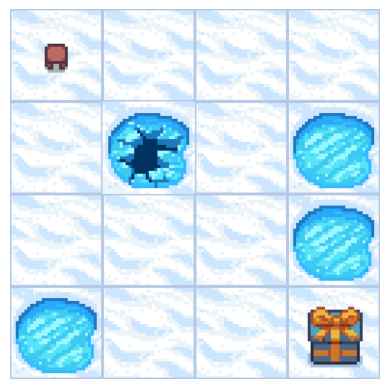

<Figure size 640x480 with 0 Axes>

[(0, np.int64(0), -1),
 (0, np.int64(0), -1),
 (0, np.int64(0), -1),
 (0, np.int64(3), -1),
 (0, np.int64(2), -1),
 (1, np.int64(3), -1),
 (1, np.int64(0), -1),
 (0, np.int64(0), -1),
 (0, np.int64(1), -1),
 (4, np.int64(1), -1),
 (8, np.int64(3), -1),
 (4, np.int64(2), -10)]

<Figure size 640x480 with 0 Axes>

In [6]:
policy = np.full((16,4),0.25)
generate_episode(env, policy, render=True, render_mode="rgb_array")

## Step 3: On-policy every-visit Monte Carlo Implementation

### 3.1 Every visit Monte Carlo prediction


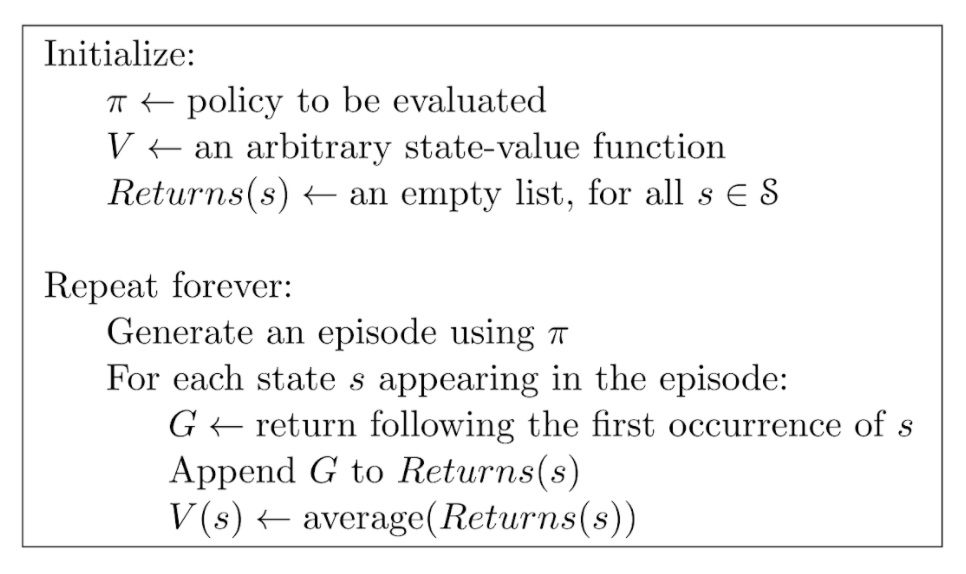

In [7]:
def every_visit_mc_prediction(policy, episode_n, gamma, env):
    #initialize
    V = np.zeros(env.observation_space.n)
    returns = [[] for _ in range(env.observation_space.n)]
    V_hist = np.zeros((episode_n, 16))

    for i in trange(episode_n):
        episode = generate_episode(env, policy, render=False)
        G = 0
        for t in range(len(episode))[::-1]:
            state, action, reward = episode[t]
            G = gamma * G + reward
            returns[state].append(G)
            V[state] = np.average(returns[state])
        V_hist[i,:] = V.copy()
    return V, V_hist


In [8]:
policy= 1/4 * np.ones((16,4))
V, V_hist = every_visit_mc_prediction(policy, 2000, 0.99, env)

  0%|          | 0/2000 [00:00<?, ?it/s]

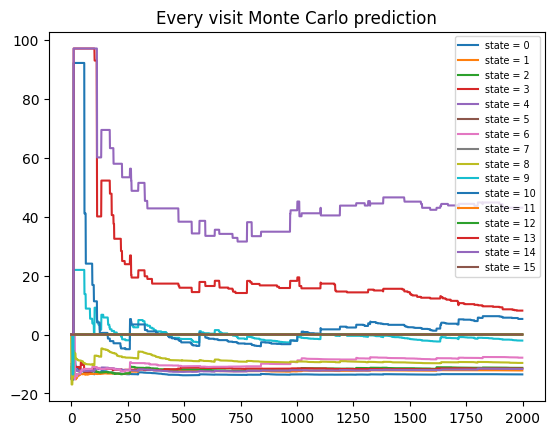

In [9]:
for i in range(16):
  plt.plot(V_hist[:,i], label = f"state = {i}")
plt.legend(loc=1, fontsize = 'x-small')
plt.title("Every visit Monte Carlo prediction")

plt.show()

In [10]:
from tabulate import tabulate
print(tabulate({f'S {round(V[0],2)}': [f'F {round(V[4],2)}', f'F {round(V[8],2)}', f'H {round(V[12],2)}'], f'F {round(V[1],2)}': [f'H {round(V[5],2)}', f'F {round(V[9],2)}', f'F {round(V[13],2)}'], f'F {round(V[2],2)}': [f'F {round(V[6],2)}', f'F {round(V[10],2)}', f'F {round(V[14],2)}'], f'F {round(V[3],2)}':[f'F {round(V[7],2)}',f'F {round(V[11],2)}',f'G {round(V[15],2)}'],}, headers="keys", tablefmt='fancy_grid', missingval='N/A'))

╒════════════╤═══════════╤════════════╤════════════╕
│ S -13.53   │ F -12.2   │ F -11.32   │ F -11.54   │
╞════════════╪═══════════╪════════════╪════════════╡
│ F -11.7    │ H 0.0     │ F -7.86    │ F 0.0      │
├────────────┼───────────┼────────────┼────────────┤
│ F -9.64    │ F -2.06   │ F 5.28     │ F 0.0      │
├────────────┼───────────┼────────────┼────────────┤
│ H 0.0      │ F 8.11    │ F 43.02    │ G 0.0      │
╘════════════╧═══════════╧════════════╧════════════╛


### Exercise 1:

Implement first-visit Monte Carlo Prediction. Plot the value functions history.

### 3.2 First-visit Monte Carlo Prediction

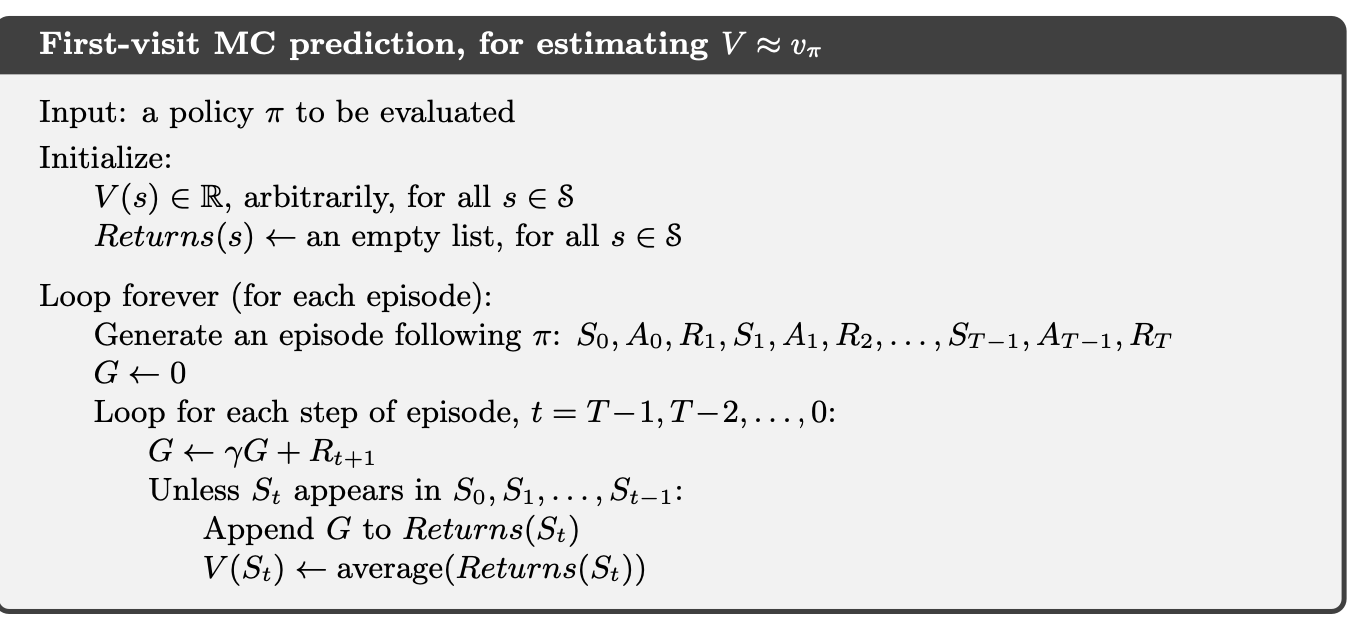

In [11]:
def first_visit_mc_prediction(policy, episode_n, gamma, env):
    V = np.zeros(env.observation_space.n)
    returns = [[] for _ in range(env.observation_space.n)]
    V_hist = np.zeros((episode_n, env.observation_space.n)) # Fixed dimension mapping to episode_n

    for i in trange(episode_n):
        episode = generate_episode(env, policy, render=False)
        G = 0
        for t in range(len(episode))[::-1]:
            state, action, reward = episode[t]

            # G MUST be updated for every step going backwards
            G = gamma * G + reward

            # First-visit check for V(s): check ONLY the state in preceding steps
            if state not in [sar[0] for sar in episode[:t]]:
                returns[state].append(G)
                V[state] = np.average(returns[state])

        V_hist[i,:] = V.copy()
    return V, V_hist

In [12]:
policy= 1/4 * np.ones((16,4))
V, V_hist = first_visit_mc_prediction(policy, 5000, 0.99, env)

  0%|          | 0/5000 [00:00<?, ?it/s]

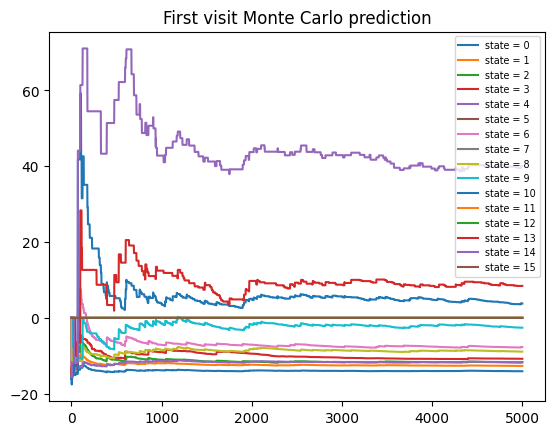

In [13]:
for i in range(16):
  plt.plot(V_hist[:,i], label = f"state = {i}")
plt.legend(loc=1, fontsize = 'x-small')
plt.title("First visit Monte Carlo prediction")

plt.show()

In [14]:
from tabulate import tabulate
print(tabulate({f'S {round(V[0],2)}': [f'F {round(V[4],2)}', f'F {round(V[8],2)}', f'H {round(V[12],2)}'], f'F {round(V[1],2)}': [f'H {round(V[5],2)}', f'F {round(V[9],2)}', f'F {round(V[13],2)}'], f'F {round(V[2],2)}': [f'F {round(V[6],2)}', f'F {round(V[10],2)}', f'F {round(V[14],2)}'], f'F {round(V[3],2)}':[f'F {round(V[7],2)}',f'F {round(V[11],2)}',f'G {round(V[15],2)}'],}, headers="keys", tablefmt='fancy_grid', missingval='N/A'))

╒════════════╤════════════╤════════════╤═══════════╕
│ S -14.08   │ F -12.66   │ F -11.73   │ F -10.8   │
╞════════════╪════════════╪════════════╪═══════════╡
│ F -11.68   │ H 0.0      │ F -7.7     │ F 0.0     │
├────────────┼────────────┼────────────┼───────────┤
│ F -8.91    │ F -2.6     │ F 3.78     │ F 0.0     │
├────────────┼────────────┼────────────┼───────────┤
│ H 0.0      │ F 8.42     │ F 40.03    │ G 0.0     │
╘════════════╧════════════╧════════════╧═══════════╛


### 3.3 Every-visit Monte Carlo Control

In [15]:
def every_visit_MC(env, num_episodes, gamma=0.9, epsilon=0.3):

    # Initializtion
    undiscounted_returns = []
    policy = np.ones((env.observation_space.n, env.action_space.n)) * (1/env.action_space.n)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    Returns = [[[] for j in range(env.action_space.n)] for i in range(env.observation_space.n)]

    for i in tqdm(range(num_episodes)):
        episode = generate_episode(env, policy, render=False)
        G = 0
        undis_return = 0
        for state, action, reward in episode[::-1]:
           G = gamma * G + reward
           undis_return += reward
           Returns[state][action].append(G)
           Q[state, action] = np.mean(Returns[state][action])
           a_max = np.argmax(Q[state])
           for a in range(env.action_space.n):
                if (a != a_max):
                    policy[state, a] = epsilon / env.action_space.n
                else:
                    policy[state, a]  = 1.0 - epsilon + epsilon/env.action_space.n
        undiscounted_returns.append(undis_return)
    return policy, undiscounted_returns

In [16]:
num_episodes = 2000
ev_MC_policy, ev_MC_returns = every_visit_MC(env, num_episodes)

  0%|          | 0/2000 [00:00<?, ?it/s]

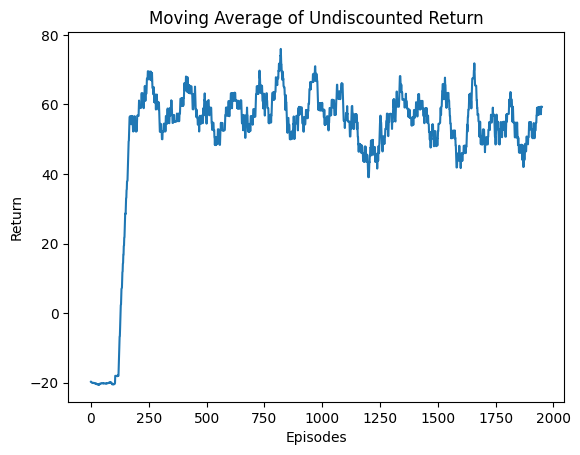

In [17]:
# Calculate a moving average over 50 episodes
window_size = 50
moving_avg = np.convolve(ev_MC_returns, np.ones(window_size)/window_size, mode='valid')

plt.plot(moving_avg)
plt.title("Moving Average of Undiscounted Return")
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.show()

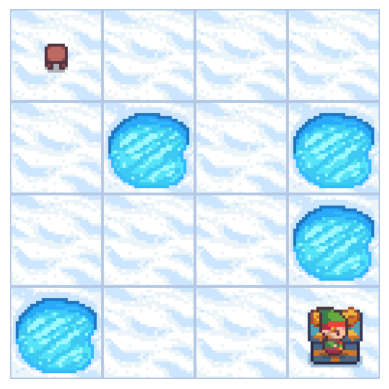

<Figure size 640x480 with 0 Axes>

[(0, np.int64(2), -1),
 (1, np.int64(2), -1),
 (2, np.int64(1), -1),
 (6, np.int64(1), -1),
 (10, np.int64(1), -1),
 (14, np.int64(2), 100)]

<Figure size 640x480 with 0 Axes>

In [18]:
generate_episode(env, ev_MC_policy, render=True, render_mode='rgb_array')

### Exercise 2:

Implement on-policy first-visit Monte Carlo algorithm.

### On-policy first-visit MC

In [19]:
def first_visit_MC(episodes_n=2000, env=env, gamma=0.9, epsilon=0.3):
    undiscounted_returns = []
    policy = np.full((env.observation_space.n,env.action_space.n),1/env.action_space.n)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    Returns = [[[] for j in range(env.action_space.n)] for i in range(env.observation_space.n)]

    for i in tqdm(range(episodes_n)):
        episode = generate_episode(env, policy)
        G = 0
        undis_return = 0
        for t, (state, action, reward) in enumerate(episode[::-1]):
            # Updates must happen OUTSIDE the conditional block
            G = gamma * G + reward
            undis_return += reward

            # t is the index in the reversed list. Original index is len(episode)-t-1
            if (state, action) not in [(sar[0], sar[1]) for sar in episode[:len(episode)-t-1]]:
                Returns[state][action].append(G)
                Q[state, action] = np.mean(Returns[state][action])
                a_max = np.argmax(Q[state])
                for a in range(env.action_space.n):
                    if (a != a_max):
                        policy[state, a] = epsilon / env.action_space.n
                    else:
                        policy[state, a]  = 1.0 - epsilon + epsilon/env.action_space.n

        undiscounted_returns.append(undis_return)
    return policy, undiscounted_returns

In [20]:
num_episodes = 5000
fv_MC_policy, fv_MC_returns = first_visit_MC(num_episodes, env)

  0%|          | 0/5000 [00:00<?, ?it/s]

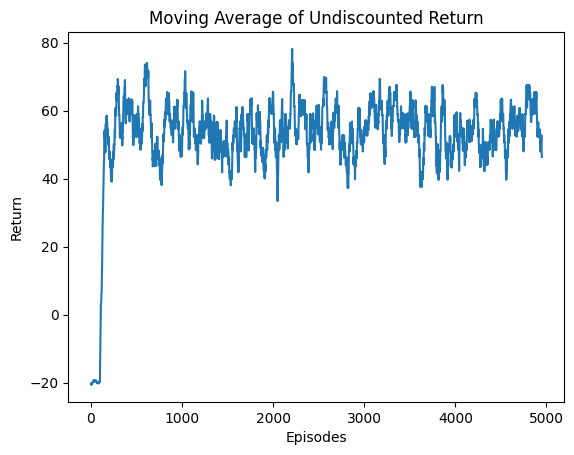

In [21]:
# Calculate a moving average over 50 episodes
window_size = 50
moving_avg = np.convolve(fv_MC_returns, np.ones(window_size)/window_size, mode='valid')

plt.plot(moving_avg)
plt.title("Moving Average of Undiscounted Return")
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.show()

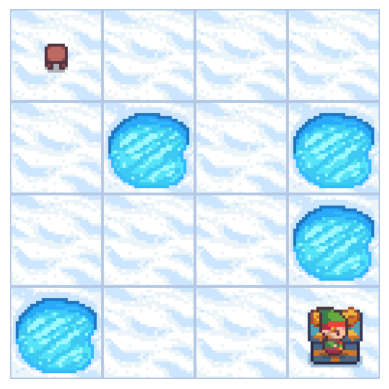

<Figure size 640x480 with 0 Axes>

[(0, np.int64(1), -1),
 (4, np.int64(1), -1),
 (8, np.int64(2), -1),
 (9, np.int64(2), -1),
 (10, np.int64(1), -1),
 (14, np.int64(2), 100)]

<Figure size 640x480 with 0 Axes>

In [22]:
generate_episode(env, fv_MC_policy, render=True, render_mode="rgb_array")

## Off-policy Weighted MC

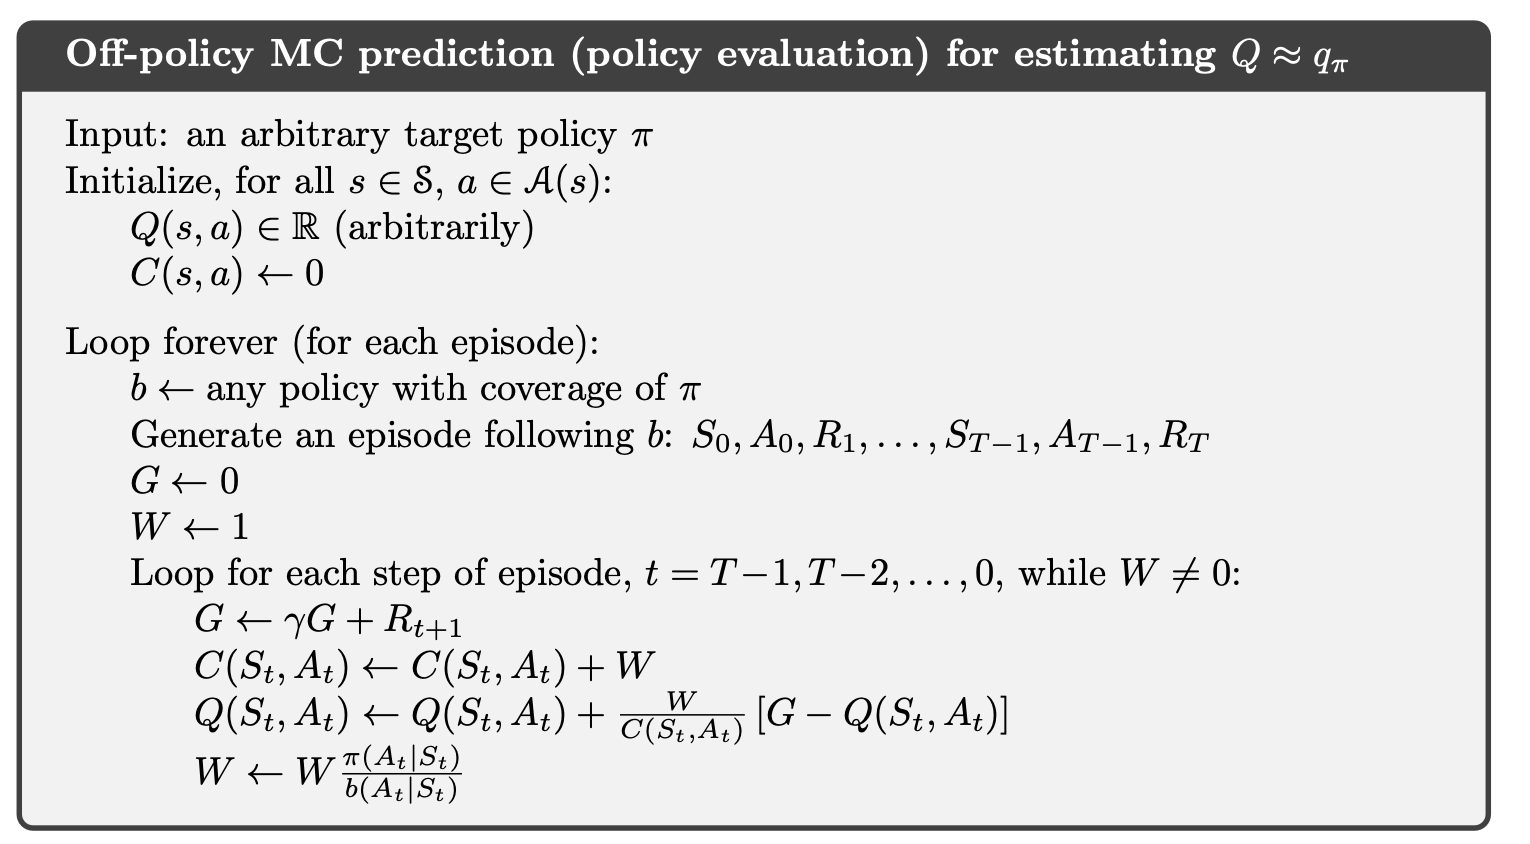

In [23]:
# Behavior Policy
b = np.ones((env.observation_space.n,env.action_space.n)) * (1/env.action_space.n)

In [24]:
def weighted_IS_MC(env, behavior_policy, target_policy, num_episodes, gamma):
    V = np.zeros(env.observation_space.n)
    # C tracks the sum of importance weights for each state
    C = np.zeros(env.observation_space.n)
    V_hist = np.zeros((num_episodes, env.observation_space.n))

    for i in range(num_episodes):
        episode = generate_episode(env, behavior_policy, render=False)
        G = 0.0
        W = 1.0

        # Iterate backwards through the episode
        for t in range(len(episode))[::-1]:
            state, action, reward = episode[t]

            G = gamma * G + reward

            # Accumulate the weight in C(S_t)
            C[state] += W

            # Update V(S_t) using Weighted Importance Sampling formula
            V[state] += (W / C[state]) * (G - V[state])

            # Update the Importance Sampling Ratio for the next step backwards
            W *= target_policy[state, action] / behavior_policy[state, action]

            # Break early if the target policy would never take this action
            if W == 0:
                break

        V_hist[i] = V.copy()

    return V, V_hist

In [28]:
# Wrapper for Weighted IS
def v_s_weighted(s):
    V_hist_weighted_s = np.zeros((10, 2000))
    for i in range(10):
        # Using the same target policy (ev_MC_policy) and behavior policy (b)
        V_weighted, V_hist_weighted = weighted_IS_MC(env, ev_MC_policy, b, 2000, 0.99)
        V_hist_weighted_s[i,:] = V_hist_weighted[:,s]
    return V_hist_weighted_s

In [29]:
def plot_many(experiments, label, color):
    mean_exp = np.mean(experiments, axis=0)
    std_exp = np.std(experiments, axis=0)
    plt.plot(mean_exp, color=color, label=label)
    plt.fill_between(range(len(experiments[0])), mean_exp + std_exp,
        mean_exp - std_exp, color=color, alpha=0.1)

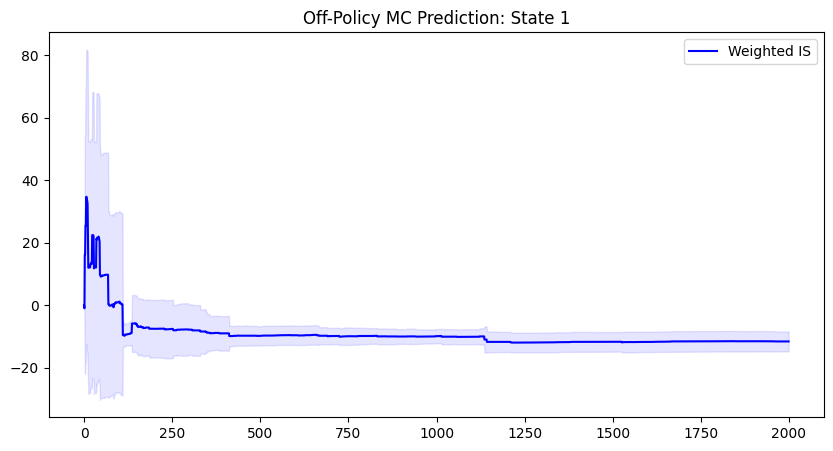

In [30]:
# Plot State 1
plt.figure(figsize=(10, 5))
V_hist_s_1_weighted = v_s_weighted(1)

plot_many(V_hist_s_1_weighted, "Weighted IS", "blue")
plt.title("Off-Policy MC Prediction: State 1")
plt.legend()
plt.show()

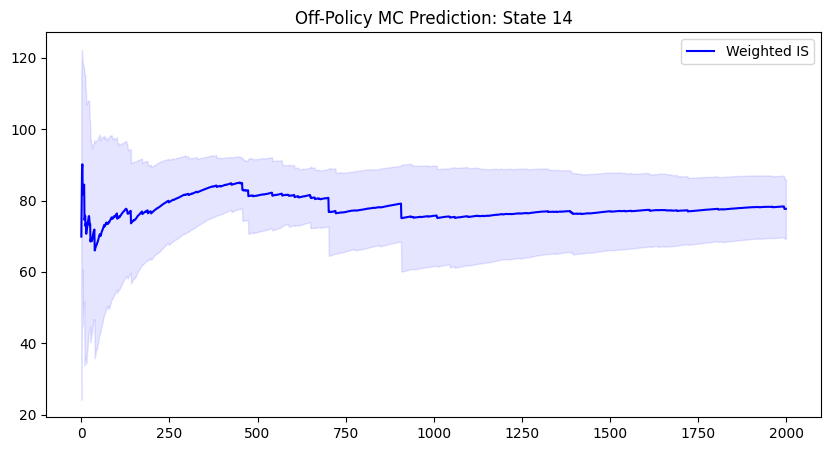

In [31]:
# Plot State 14
plt.figure(figsize=(10, 5))
V_hist_s_14_weighted = v_s_weighted(14)

plot_many(V_hist_s_14_weighted, "Weighted IS", "blue")
plt.title("Off-Policy MC Prediction: State 14")
plt.legend()
plt.show()

### Exercise 3:

Implement Monte Carlo methods for FrozenLake with `is_slippery=True`